In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_excel("Clean_Fitness_Dataset_Jivan Mule.xlsx")
df

,ActivitySiteID,ActivityDescription,BookingEndDate,BookingStartTime,MaxBookees,Number Booked,Price (INR)
0,BRP,20:20:20 9.30-10.30am,2018-06-01,1900-01-01 09:30:00,35,28,499
1,BRP,20:20:20 9.30-10.30am,2018-06-08,1900-01-01 09:30:00,35,35,499
2,BRP,20:20:20 9.30-10.30am,2018-06-15,1900-01-01 09:30:00,35,31,499
3,BRP,20:20:20 9.30-10.30am,2018-06-22,1900-01-01 09:30:00,35,32,499
4,BRP,20:20:20 9.30-10.30am,2018-06-29,1900-01-01 09:30:00,35,19,499
...,...,...,...,...,...,...,...
3284,NBL,Zumba Gold 12.45-1.45pm,2018-05-01,1900-01-01 12:45:00,60,47,1999
3285,NBL,Zumba Gold 12.45-1.45pm,2018-05-08,1900-01-01 12:45:00,60,42,1999
3286,NBL,Zumba Gold 12.45-1.45pm,2018-05-15,1900-01-01 12:45:00,60,38,1999
3287,NBL,Zumba Gold 12.45-1.45pm,2018-05-22,1900-01-01 12:45:00,60,39,1999


In [14]:
df.head()

,ActivitySiteID,ActivityDescription,BookingEndDate,BookingStartTime,MaxBookees,Number Booked,Price (INR)
0,BRP,20:20:20 9.30-10.30am,2018-06-01,1900-01-01 09:30:00,35,28,499
1,BRP,20:20:20 9.30-10.30am,2018-06-08,1900-01-01 09:30:00,35,35,499
2,BRP,20:20:20 9.30-10.30am,2018-06-15,1900-01-01 09:30:00,35,31,499
3,BRP,20:20:20 9.30-10.30am,2018-06-22,1900-01-01 09:30:00,35,32,499
4,BRP,20:20:20 9.30-10.30am,2018-06-29,1900-01-01 09:30:00,35,19,499


Data Understanding

In [12]:
df.shape

(3289, 7)

In [13]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3289 entries, 0 to 3288
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   ActivitySiteID       3289 non-null   str           
 1   ActivityDescription  3289 non-null   str           
 2   BookingEndDate       3289 non-null   datetime64[us]
 3   BookingStartTime     3289 non-null   datetime64[us]
 4   MaxBookees           3289 non-null   int64         
 5   Number Booked        3289 non-null   int64         
 6   Price (INR)          3289 non-null   int64         
dtypes: datetime64[us](2), int64(3), str(2)
memory usage: 180.0 KB


In [15]:
df.columns

Index(['ActivitySiteID', 'ActivityDescription', 'BookingEndDate',
       'BookingStartTime', 'MaxBookees', 'Number Booked', 'Price (INR)'],
      dtype='str')

Prepare Time Series Data

In [16]:
#Group by Date
daily_demand = (
    df.groupby("BookingEndDate")["Number Booked"]
      .sum()
      .reset_index()
)

In [19]:
daily_demand.head()

,BookingEndDate,Number Booked
0,2018-04-01,223
1,2018-04-02,296
2,2018-04-03,973
3,2018-04-04,905
4,2018-04-05,695


In [ ]:
#set data as index
daily_demand.set_index("BookingEndDate", inplace=True)

In [23]:
daily_demand.head()

,Number Booked
BookingEndDate,
2018-04-01,223
2018-04-02,296
2018-04-03,973
2018-04-04,905
2018-04-05,695


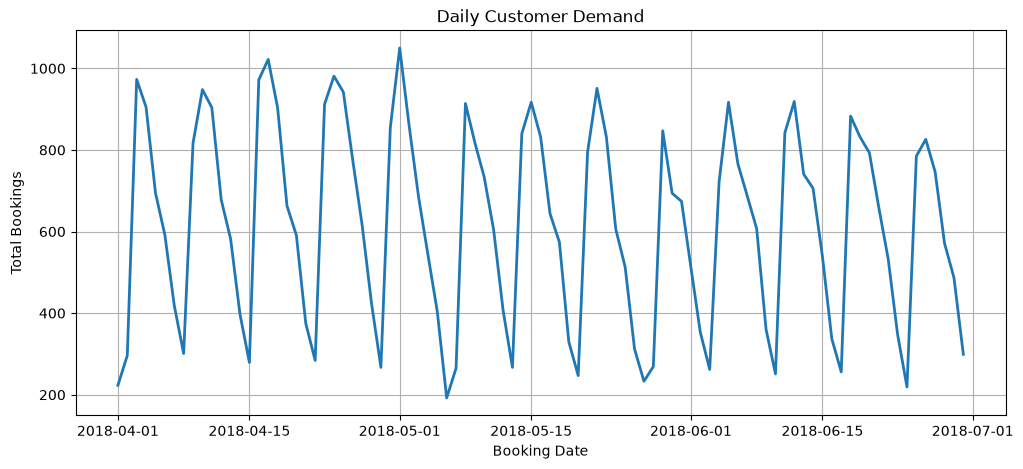

In [24]:
plt.figure(figsize=(12,5))

plt.plot(daily_demand.index,
         daily_demand["Number Booked"],
         linewidth=2)

plt.title("Daily Customer Demand")
plt.xlabel("Booking Date")
plt.ylabel("Total Bookings")

plt.grid(True)

plt.show()

To visualize daily customer booking demand and identify demand patterns over time.
Daily booking demand shows regular fluctuations with several high-demand and low-demand days. The overall demand remains stable throughout the three-month period.

In [ ]:
#Stationarity Test  Augmented Dickey-Fuller Test (ADF Test)
from statsmodels.tsa.stattools import adfuller

result = adfuller(daily_demand["Number Booked"])

print("ADF Statistic :", result[0])
print("p-value :", result[1])

if result[1] < 0.05:
    print("The time series is Stationary")
else:
    print("The time series is Non-Stationary")

ADF Statistic : -2.2405174710828053
p-value : 0.19186983736946034
The time series is Non-Stationary


In [26]:
#Make data stationary
daily_diff = daily_demand["Number Booked"].diff().dropna()

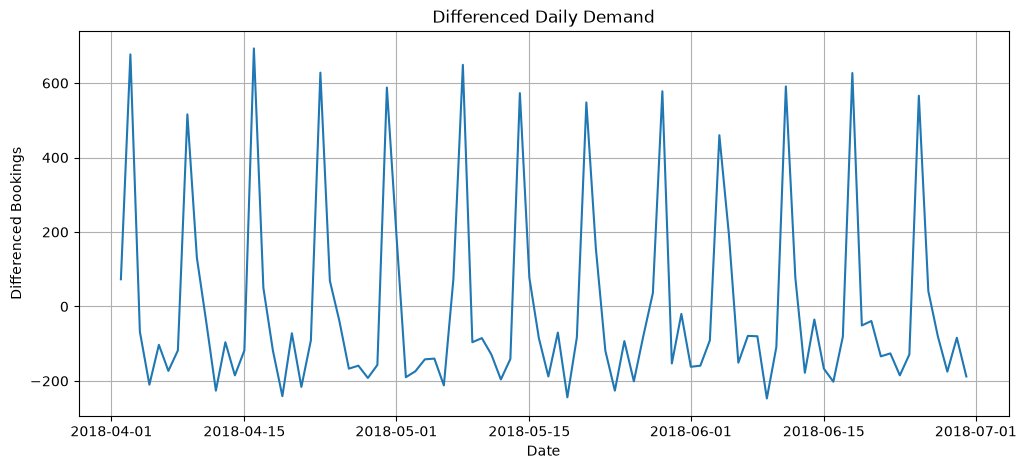

In [27]:
plt.figure(figsize=(12,5))

plt.plot(daily_diff)

plt.title("Differenced Daily Demand")

plt.xlabel("Date")

plt.ylabel("Differenced Bookings")

plt.grid(True)

plt.show()

In [28]:
#again check ADF
result = adfuller(daily_diff)

print("ADF Statistic :", result[0])
print("p-value :", result[1])

if result[1] < 0.05:
    print("The Differenced Series is Stationary")
else:
    print("Still Non-Stationary")

ADF Statistic : -15.16351767585984
p-value : 6.539992448387423e-28
The Differenced Series is Stationary


Model Training

In [29]:
#Train-Test Split (Time Series)
train_size = int(len(daily_demand) * 0.8)

train = daily_demand["Number Booked"][:train_size]
test = daily_demand["Number Booked"][train_size:]

print("Training Data :", len(train))
print("Testing Data :", len(test))

Training Data : 72
Testing Data : 19


Train the ARIMA Model

In [ ]:
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(train, order=(5,1,0))

model_fit = model.fit()

print(model_fit.summary())


"""The ADF test showed that the original series was non-stationary. 
 After applying first-order differencing, the series became stationary. 
 Therefore, I selected d = 1. For the initial model, I used ARIMA(5,1,0) as a baseline forecasting model, 
 which can later be tuned based on AIC/BIC values or ACF/PACF analysis."""

                               SARIMAX Results                                
Dep. Variable:          Number Booked   No. Observations:                   72
Model:                 ARIMA(5, 1, 0)   Log Likelihood                -465.300
Date:                Tue, 21 Jul 2026   AIC                            942.599
Time:                        15:35:45   BIC                            956.175
Sample:                    04-01-2018   HQIC                           947.998
                         - 06-11-2018                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.3207      0.115     -2.799      0.005      -0.545      -0.096
ar.L2         -0.5705      0.127     -4.500      0.000      -0.819      -0.322
ar.L3         -0.5029      0.164     -3.069      0.0

c:\Users\Asus\OneDrive\Desktop\Dynamic-pricing-strategies-for-fitness-classes\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\Asus\OneDrive\Desktop\Dynamic-pricing-strategies-for-fitness-classes\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\Asus\OneDrive\Desktop\Dynamic-pricing-strategies-for-fitness-classes\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


Forecast on Test Data

In [ ]:
forecast = model_fit.forecast(steps=len(test))

In [32]:
forecast

2018-06-12    928.460148
2018-06-13    782.076158
2018-06-14    700.484946
2018-06-15    581.893641
2018-06-16    295.114427
2018-06-17    500.583712
2018-06-18    794.612348
2018-06-19    835.654019
2018-06-20    759.170869
2018-06-21    719.552463
2018-06-22    484.492429
2018-06-23    400.422141
2018-06-24    586.769040
2018-06-25    763.270921
2018-06-26    773.271476
2018-06-27    774.481733
2018-06-28    655.586717
2018-06-29    482.074205
2018-06-30    478.998191
Freq: D, Name: predicted_mean, dtype: float64

Compare Actual vs Forecast

In [33]:
comparison = pd.DataFrame({
    "Actual": test,
    "Forecast": forecast
})

comparison.head(10)

,Actual,Forecast
2018-06-12,919,928.460148
2018-06-13,741,782.076158
2018-06-14,706,700.484946
2018-06-15,539,581.893641
2018-06-16,337,295.114427
2018-06-17,256,500.583712
2018-06-18,883,794.612348
2018-06-19,832,835.654019
2018-06-20,793,759.170869
2018-06-21,659,719.552463


Model Evaluation

In [34]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(test, forecast)
mse = mean_squared_error(test, forecast)
rmse = np.sqrt(mse)

print("MAE  :", round(mae,2))
print("MSE  :", round(mse,2))
print("RMSE :", round(rmse,2))

MAE  : 74.37
MSE  : 13781.93
RMSE : 117.4


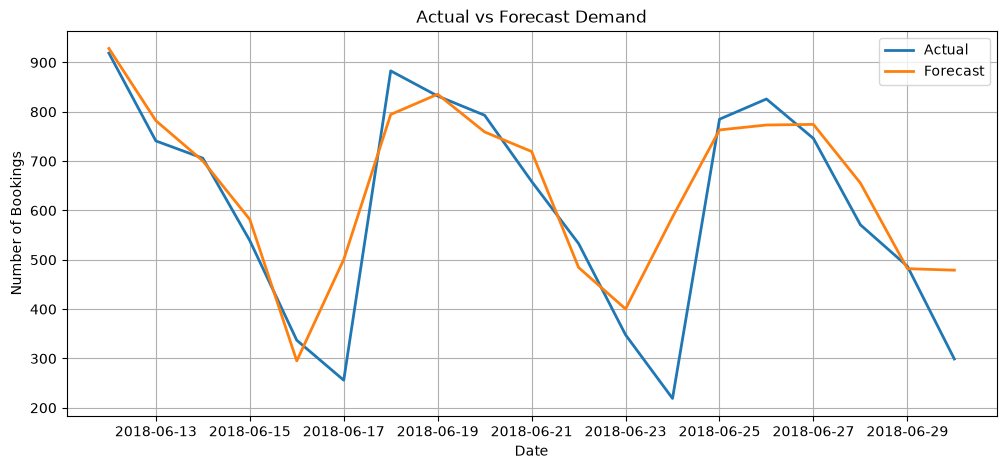

In [35]:
plt.figure(figsize=(12,5))

plt.plot(test.index, test, label="Actual", linewidth=2)
plt.plot(test.index, forecast, label="Forecast", linewidth=2)

plt.title("Actual vs Forecast Demand")
plt.xlabel("Date")
plt.ylabel("Number of Bookings")

plt.legend()
plt.grid(True)

plt.show()

Actual vs Forecast Graph Insights

Objective
To compare actual customer demand with forecasted demand and evaluate forecasting performance.

Observation
The forecast line closely follows the actual booking trend for most of the testing period.
The model successfully captures the overall demand pattern.
Prediction errors are higher on days with sudden demand spikes or sharp drops.
Business Insight
The forecasting model provides reliable demand estimates, enabling the business to plan pricing strategies, staffing, and resource allocation in advance.

Conclusion
This project successfully implemented a demand forecasting model using the ARIMA algorithm to predict future customer bookings for fitness classes. The model was trained on historical booking data and evaluated using MAE, MSE, and RMSE. The forecasting results demonstrated that the model effectively captured the overall demand pattern and can support data-driven business decisions.